In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import linregress
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import re
from tqdm import tqdm

%load_ext autoreload
%autoreload 2

from utils import load_excel_sheets, process_benchmark_stats, aggregate_stats, global_model_list

# Data unpacking

In [3]:
dfs = load_excel_sheets('../data/PB2/P2')

print("\nLoaded dataframe keys:", list(dfs.keys()))

 Loaded: Human_ms.xlsx Sheets:[3/3]
 Loaded: Gemini 2.5_ms.xlsx Sheets:[3/3]
 Loaded: DeepSeek-V3.2_ms.xlsx Sheets:[3/3]
 Loaded: Gemini 3.0_ms.xlsx Sheets:[3/3]
 Loaded: ChatGPT-5.1_ms.xlsx Sheets:[3/3]

Loaded dataframe keys: ['P2_Human_CM', 'P2_Human_EM', 'P2_Human_QM', 'P2_Gemini 2.5_CM', 'P2_Gemini 2.5_EM', 'P2_Gemini 2.5_QM', 'P2_DeepSeek-V3.2_CM', 'P2_DeepSeek-V3.2_EM', 'P2_DeepSeek-V3.2_QM', 'P2_Gemini 3.0_CM', 'P2_Gemini 3.0_EM', 'P2_Gemini 3.0_QM', 'P2_ChatGPT-5.1_CM', 'P2_ChatGPT-5.1_EM', 'P2_ChatGPT-5.1_QM']


In [4]:
process_benchmark_stats(dfs)
# Verify the result with the first dataframe
if dfs:
    first_key = list(dfs.keys())[0]
    print(f"\nFirst 5 rows of {first_key}:")
    display(dfs[first_key].head())

Processing DataFrames: 100%|██████████| 15/15 [00:00<00:00, 791.22it/s]


First 5 rows of P2_Human_CM:


,Question Number,Available Marks,Solution 1,Solution 2,Solution 3,Dir,Model,Sheet,key,mean solution,std solution,mean percentage mark,std percentage
0,1,6,5,5,5,P2,Human,CM,P2_Human_CM,5.0,0.000000,83.333333,0.000000
1,2,9,9,9,3,P2,Human,CM,P2_Human_CM,7.0,3.464102,77.777778,38.490018
2,3,13,11,13,9,P2,Human,CM,P2_Human_CM,11.0,2.000000,84.615385,15.384615
3,4,10,6,6,6,P2,Human,CM,P2_Human_CM,6.0,0.000000,60.000000,0.000000
4,5,7,7,7,7,P2,Human,CM,P2_Human_CM,7.0,0.000000,100.000000,0.000000


In [5]:
# Create master df and summary df for plotting
master_df, summary_stats = aggregate_stats(dfs)

display(master_df.head())
display(summary_stats.head())

/Users/jonah/Github - Projects/LLM Project paper/AI-in-Physics-in-Education-j/Plot code/utils.py:128: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary_stats = master_df.groupby(['Dir', 'Model', 'Sheet']).agg(


,Question Number,Available Marks,Solution 1,Solution 2,Solution 3,Dir,Model,Sheet,key,mean solution,std solution,mean percentage mark,std percentage
18,1,6,6,6,6,P2,Gemini 2.5,CM,P2_Gemini 2.5_CM,6.000000,0.000000,100.000000,0.000000
19,2,9,9,9,8,P2,Gemini 2.5,CM,P2_Gemini 2.5_CM,8.666667,0.577350,96.296296,6.415003
20,3,13,11,8,7,P2,Gemini 2.5,CM,P2_Gemini 2.5_CM,8.666667,2.081666,66.666667,16.012815
21,4,10,5,8,8,P2,Gemini 2.5,CM,P2_Gemini 2.5_CM,7.000000,1.732051,70.000000,17.320508
22,5,7,4,3,7,P2,Gemini 2.5,CM,P2_Gemini 2.5_CM,4.666667,2.081666,66.666667,29.738086


,Dir,Model,Sheet,Total_Mean%,Total_Std,Total_Std_error%
0,P2,Gemini 2.5,CM,78.616352,15.038436,6.139416
1,P2,Gemini 2.5,EM,53.741497,32.743387,13.367432
2,P2,Gemini 2.5,QM,82.485876,15.241964,6.222506
3,P2,ChatGPT-5.1,CM,88.679245,11.306199,4.615736
4,P2,ChatGPT-5.1,EM,68.027211,25.319749,10.336744


# Bar Plots

,Dir,Model,Sheet,Total_Mean%,Total_Std,Total_Std_error%
0,P2,Gemini 2.5,CM,78.616352,15.038436,6.139416
3,P2,ChatGPT-5.1,CM,88.679245,11.306199,4.615736
6,P2,Gemini 3.0,CM,86.163522,14.909121,6.086623
9,P2,DeepSeek-V3.2,CM,81.761006,16.367271,6.681911
12,P2,Human,CM,83.018868,15.013610,6.129281


Dirs: ['P2']
Sheets: ['CM' 'EM' 'QM']


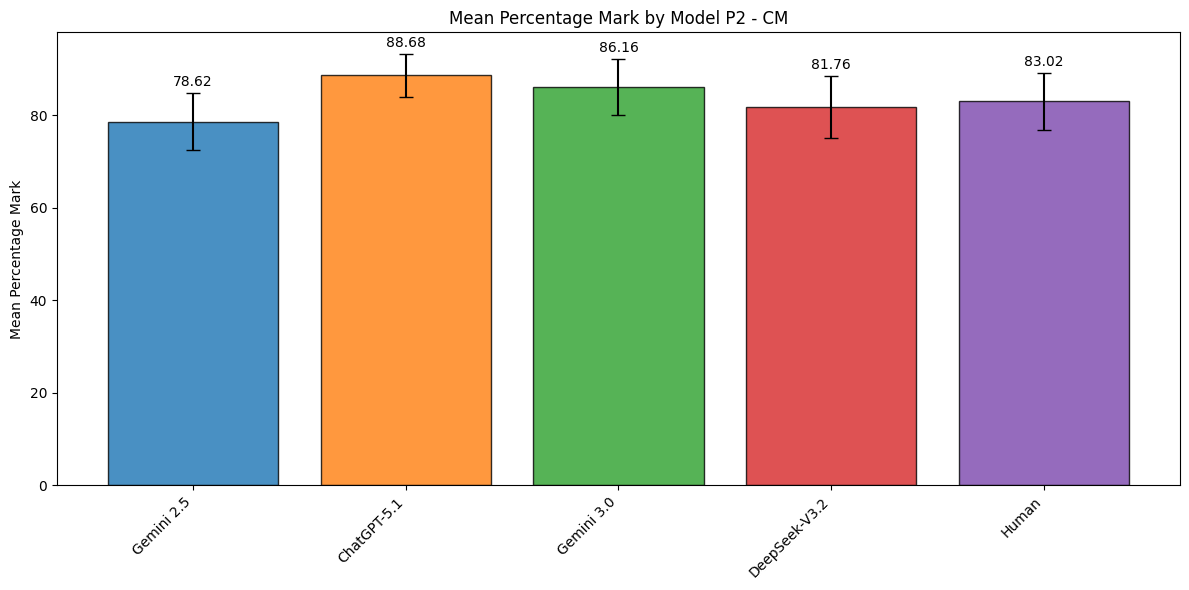

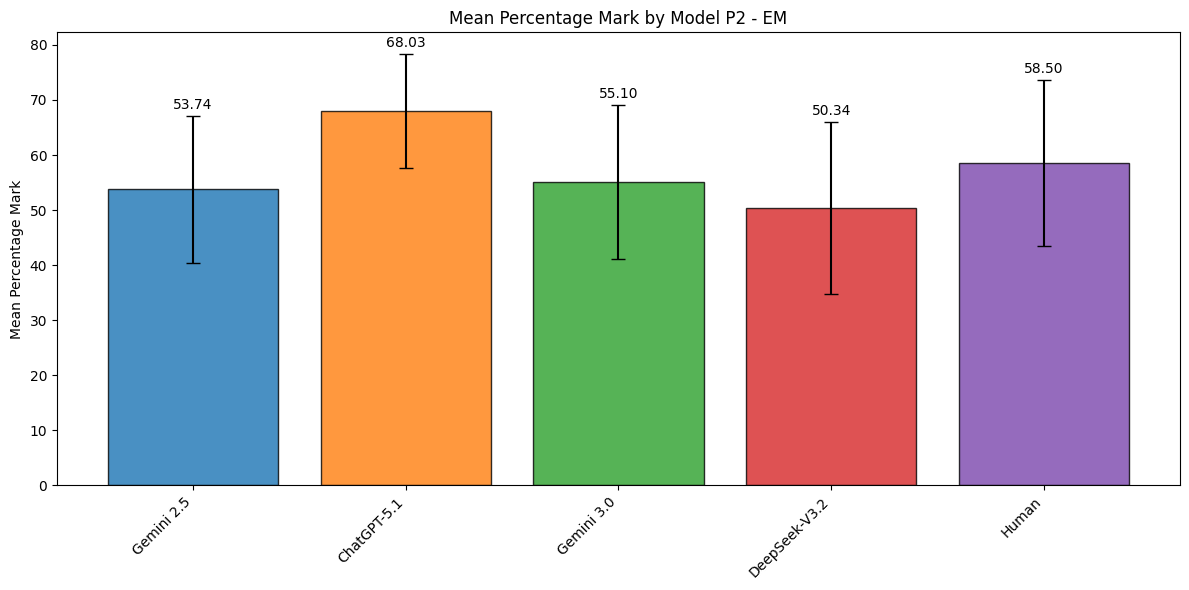

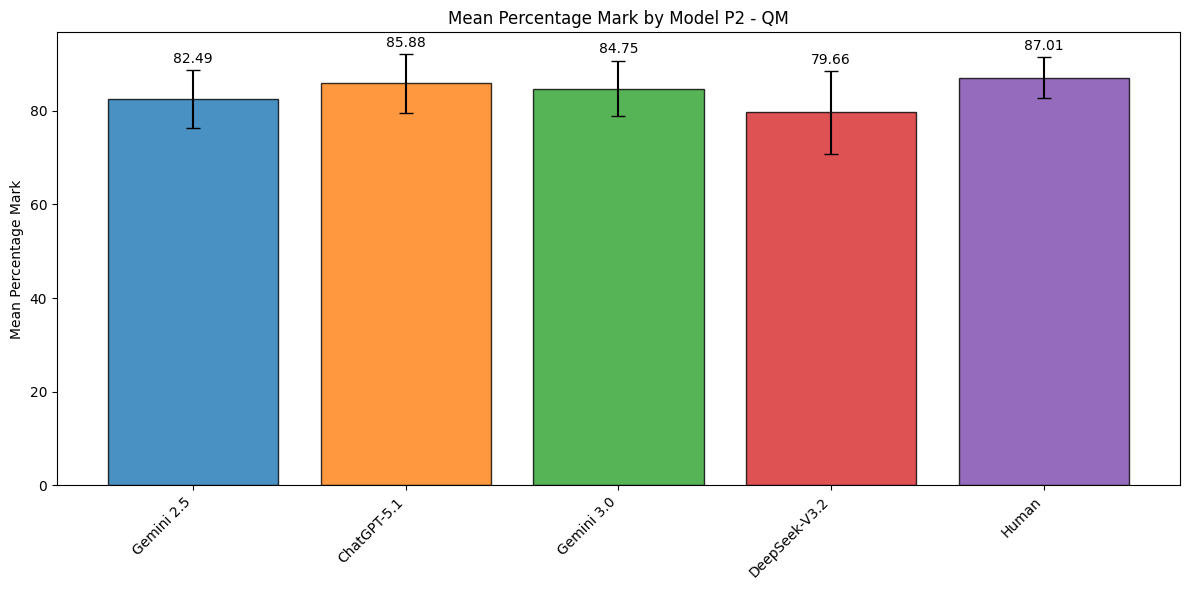

In [6]:
# Get relevant models
unique_models = master_df['Model'].unique()
model_list = [model for model in global_model_list if model in unique_models]
topic_sheet_df = summary_stats.groupby(['Dir','Sheet'])

display(topic_sheet_df.get_group(('P2', 'CM')))

# Get unique dirs and sheets for plotting
dir_list = master_df['Dir'].unique()
sheet_list = master_df['Sheet'].unique()

print("Dirs:", dir_list)
print("Sheets:", sheet_list)

# Colors
colors = ["#1b75b5", '#ff7f0e', '#2ca02c', '#d62728', "#7b46ad", '#8c564b']

safe_colors = (colors * 3) 

for dir in dir_list:
    for sheet in sheet_list:
        # Extract data
        try:
            group = topic_sheet_df.get_group((dir, sheet))
        except KeyError:
            continue # Skip completely if this Dir/Sheet combo doesn't exist
            
        group = group.dropna(subset=['Total_Mean%'])
        
        # If dropping the missing models leaves the group completely empty, skip plotting
        if group.empty:
            continue

        # 1. Grab the exact models and stats present in THIS specific group
        current_models = group['Model']
        means = group['Total_Mean%']
        std_errs = group['Total_Std_error%']

        fig, ax = plt.subplots(figsize=(12, 6))

        # 2. Set X to match the actual number of rows left in the group
        x = np.arange(len(current_models)) 
        
        # 3. Slice the colors to match the exact number of bars
        current_colors = safe_colors[:len(x)]
        
        # Plotting
        rects1 = ax.bar(x, means, width=0.8, yerr=std_errs, 
                        capsize=5, color=current_colors, edgecolor='black', alpha=0.8)

        ax.set_ylabel('Mean Percentage Mark')
        ax.set_title(f'Mean Percentage Mark by Model {dir} - {sheet}')
        ax.set_xticks(x)
        
        # 4. Use the current_models for the labels so they align perfectly
        ax.set_xticklabels(current_models, rotation=45, ha='right')

        # Add labels 
        ax.bar_label(rects1, padding=3, fmt='%.2f')

        plt.tight_layout()
        plt.show()

# Delta bar plots

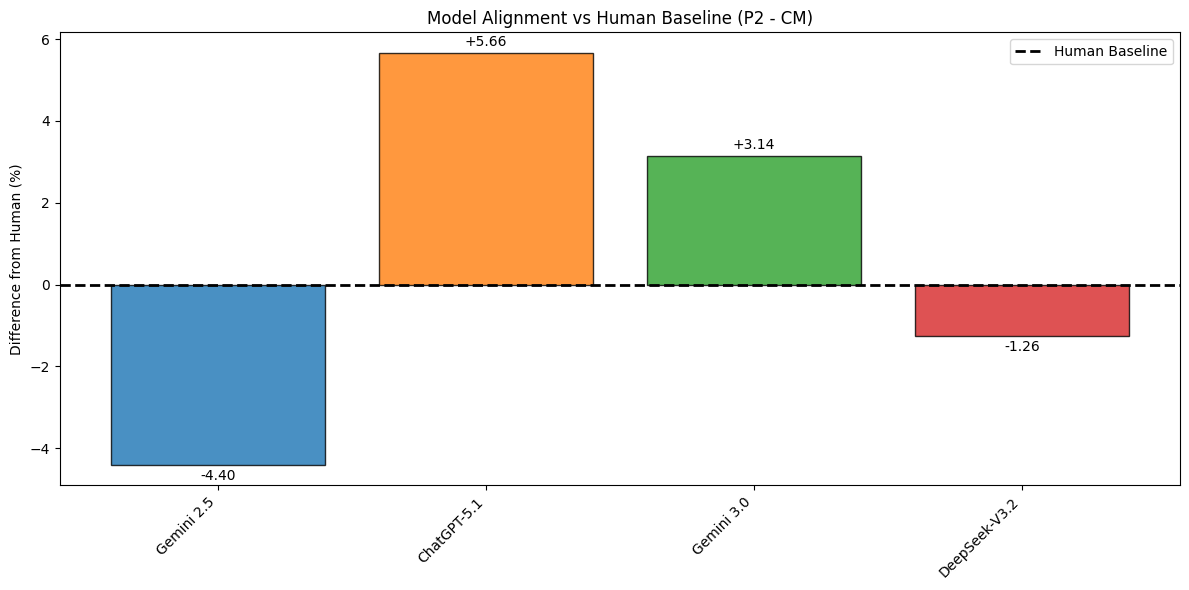

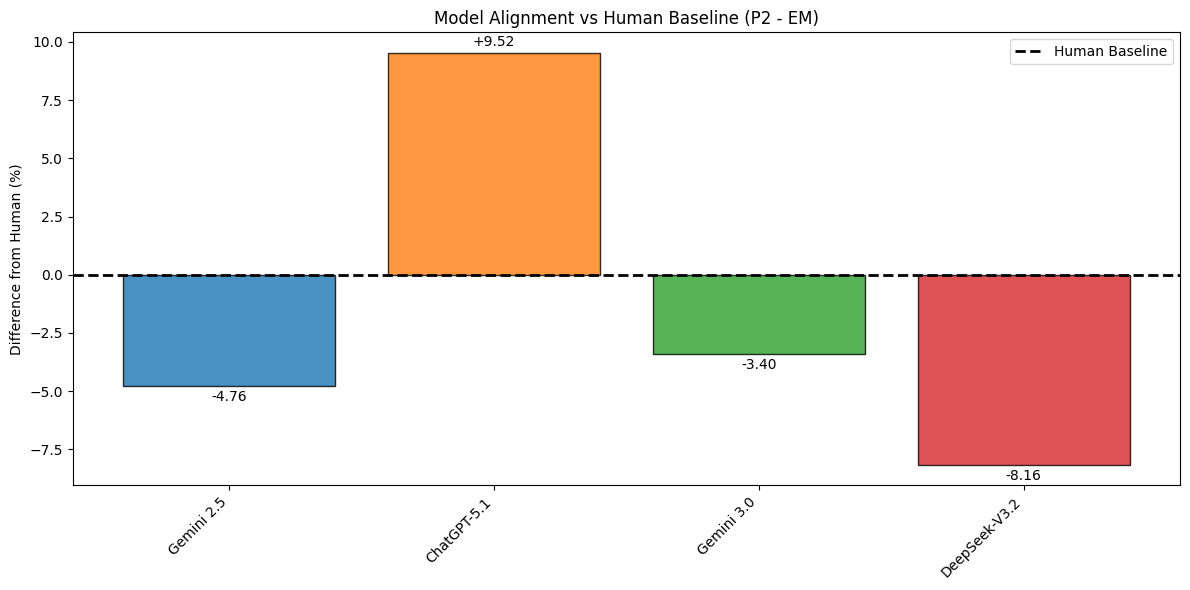

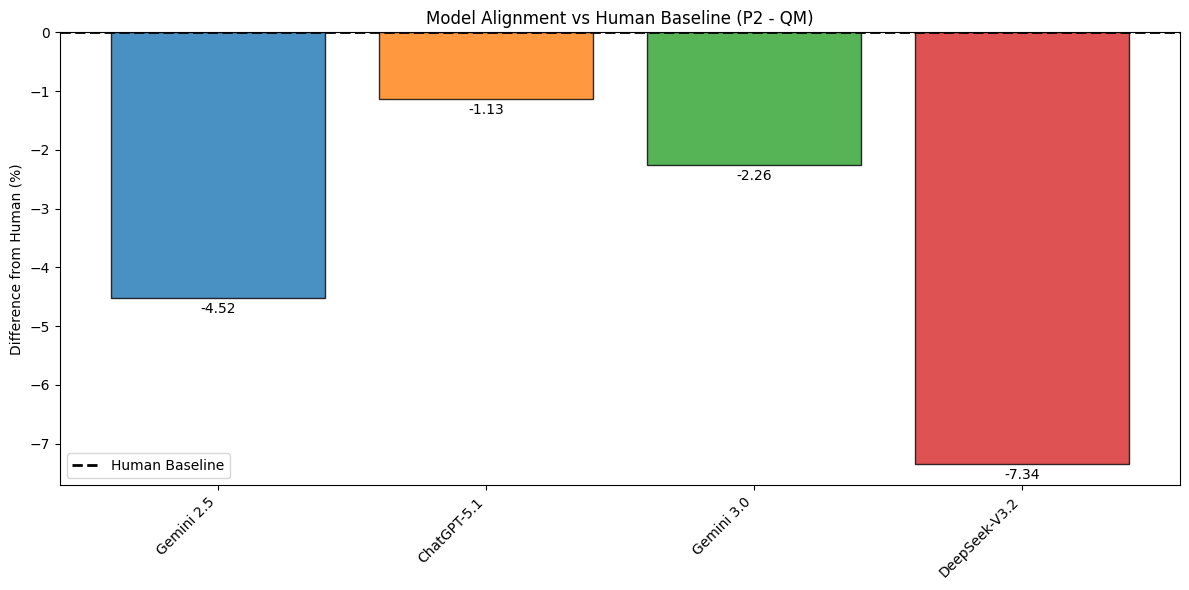

In [7]:
safe_colors = (colors * 3) 

for dir in dir_list: # Only loop through the dirs that have human data
    for sheet in sheet_list:
        try:
            group = topic_sheet_df.get_group((dir, sheet)).dropna(subset=['Total_Mean%'])
        except KeyError:
            continue
            
        if group.empty or 'Human' not in group['Model'].values:
            continue # Skip if no human data to compare against

        # 1. Isolate the Human Baseline
        human_score = group.loc[group['Model'] == 'Human', 'Total_Mean%'].values[0]

        # 2. Calculate the Delta (Difference from Human)
        group = group.copy()
        group['Delta_from_Human'] = group['Total_Mean%'] - human_score
        
        # (Optional) Drop the Human row from the plot so it doesn't just show a 0 bar
        plot_group = group[group['Model'] != 'Human']
        
        current_models = plot_group['Model']
        deltas = plot_group['Delta_from_Human']

        fig, ax = plt.subplots(figsize=(12, 6))
        x = np.arange(len(current_models)) 
        current_colors = safe_colors[:len(x)]
        
        # Plotting the differences
        rects1 = ax.bar(x, deltas, width=0.8, color=current_colors, edgecolor='black', alpha=0.8)

        # Draw a thick line at 0 (The Human Baseline)
        ax.axhline(0, color='black', linewidth=2, linestyle='--', label='Human Baseline')

        ax.set_ylabel('Difference from Human (%)')
        ax.set_title(f'Model Alignment vs Human Baseline ({dir} - {sheet})')
        ax.set_xticks(x)
        ax.set_xticklabels(current_models, rotation=45, ha='right')
        ax.legend()

        # Add labels (adds a '+' sign if the model beat the human)
        ax.bar_label(rects1, padding=3, fmt='%+.2f')

        plt.tight_layout()
        plt.show()

# Lingress

/var/folders/17/723pj1316pl5m9z25hgjlqbc0000gn/T/ipykernel_88017/3336128651.py:7: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  question_pivot = dir_df.pivot_table(



--- Alignment & IRR Statistics for Directory: P2 ---
        Model  Gradient (Slope)  Y-Intercept  Pearson r (IRR)  R-squared  MAE (Avg Disagreement %)  RMSE vs Human (%)  Slope Std Error
   Gemini 2.5            0.7644      16.8866           0.8115     0.6585                   12.5810            15.1483           0.1376
  ChatGPT-5.1            0.6892      30.7072           0.9175     0.8417                    9.1561            12.7508           0.0747
   Gemini 3.0            0.9002       9.6095           0.9191     0.8448                    7.6185            10.2201           0.0965
DeepSeek-V3.2            0.9603       2.0947           0.8719     0.7602                    9.5033            13.6643           0.1349



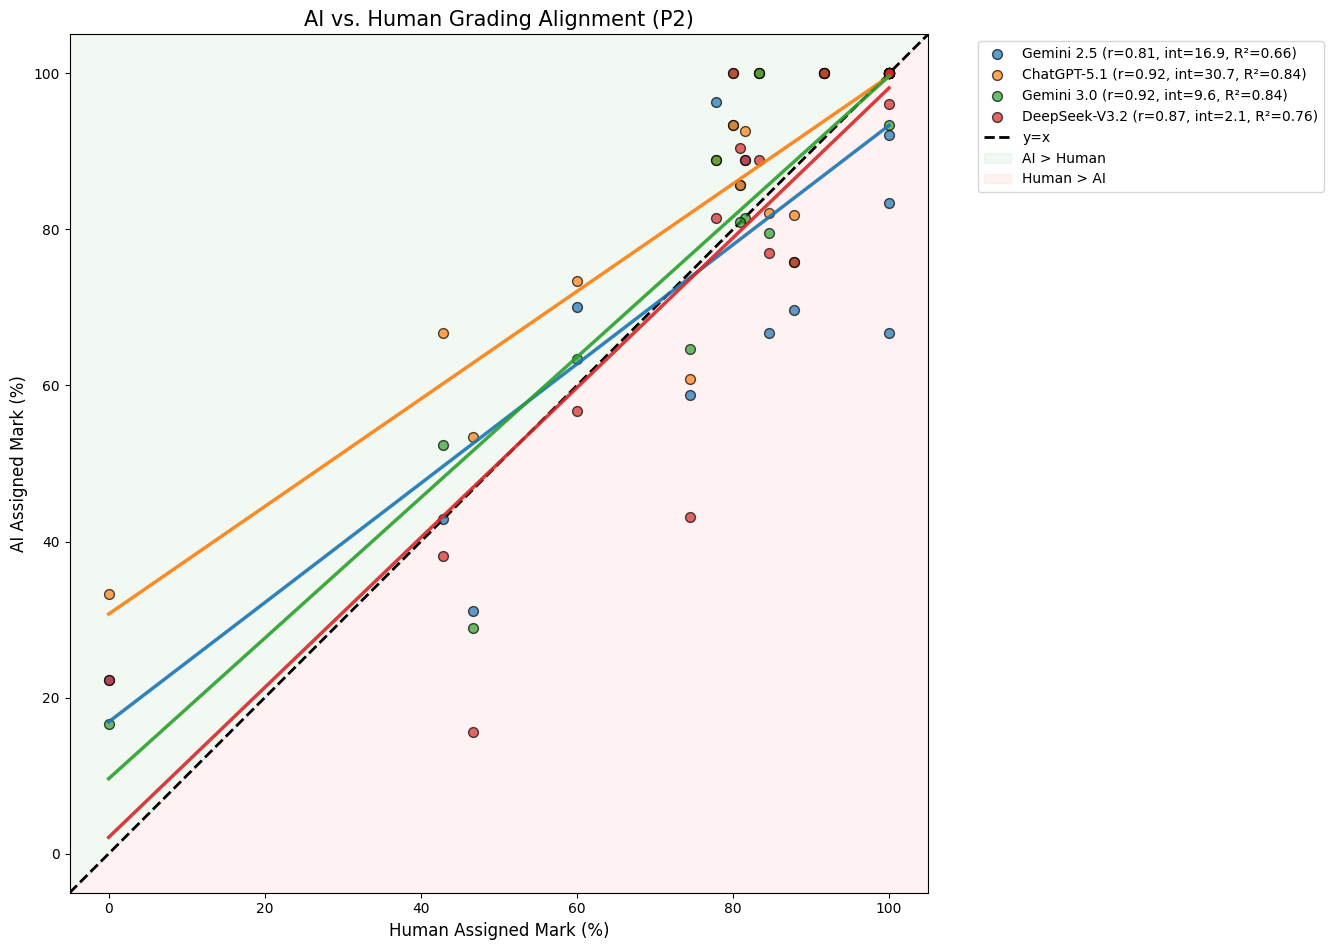

In [10]:
# Pivot table loop
for current_dir in ['P2']:
    # Filter the master_df for just this specific directory
    dir_df = master_df[master_df['Dir'] == current_dir]

    # Pivot the data for just this directory
    question_pivot = dir_df.pivot_table(
        index=['Sheet', 'Question Number'], 
        columns='Model', 
        values='mean percentage mark' 
    ).reset_index()

    fig, ax = plt.subplots(figsize=(12, 10))

    # Separate AI models from the Human baseline (preserves your original list order)
    ai_models = [m for m in model_list if m in question_pivot.columns and m != 'Human']
    
    # List to store our text statistics
    stats_list = []

    # Plot linear regression
    for i, model in enumerate(ai_models):
        if question_pivot[model].notna().any():
            x = question_pivot['Human'].astype(float)
            y = question_pivot[model].astype(float)
        
            # A. Calculate Linear Regression with scipy FIRST
            res = linregress(x, y)
            slope, intercept = res.slope, res.intercept
            slope_stderr = res.stderr
            pearson_r = res.rvalue        
            r_squared = pearson_r ** 2    
            
            # Calculate RMSE and MAE vs Human logic
            rmse = np.sqrt(np.mean((y - x)**2))
            mae = np.mean(np.abs(y - x))  
            
            # Save stats for the text printout 
            stats_list.append({
                'Model': model,
                'Gradient (Slope)': slope,
                'Y-Intercept': intercept,
                'Pearson r (IRR)': pearson_r,
                'R-squared': r_squared,
                'MAE (Avg Disagreement %)': mae,
                'RMSE vs Human (%)': rmse,
                'Slope Std Error': slope_stderr
            })

            # B. Draw the Scatter Points 
            label_text = f"{model} (r={pearson_r:.2f}, int={intercept:.1f}, R²={r_squared:.2f})"
            ax.scatter(x, y, label=label_text, color=colors[i], 
                       s=50, alpha=0.7, edgecolors='black', zorder=3)
            
            # C. Draw the Regression Line
            x_vals = np.array([0, 100]) 
            y_vals = slope * x_vals + intercept
            ax.plot(x_vals, y_vals, color=colors[i], linestyle='-', 
                    linewidth=2.5, alpha=0.9, zorder=4)

    # ==========================================
    # --- PRINT THE TEXT STATISTICS ---
    # ==========================================
    print(f"\n{'='*135}")
    print(f"--- Alignment & IRR Statistics for Directory: {current_dir} ---")
    print(f"{'='*135}")
    if stats_list:
        stats_df = pd.DataFrame(stats_list)
        # REMOVED SORTING: Data prints exactly in the order of model_list
        print(stats_df.to_string(index=False, float_format="%.4f"))
    else:
        print("No comparative data available.")
    print(f"{'='*135}\n")

    # ==========================================
    # --- DRAW THE SCATTER PLOT ---
    # ==========================================
    min_val, max_val = -0, 100
    ax.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=2, label='y=x', zorder=2)

    ax.set_xlabel('Human Assigned Mark (%)', fontsize=12)
    ax.set_ylabel('AI Assigned Mark (%)', fontsize=12)
    ax.set_title(f'PB2: AI vs. Human Grading Alignment', fontsize=15)

    ax.fill_between([min_val, max_val], [min_val, max_val], max_val, color='green', alpha=0.05, label='AI > Human')
    ax.fill_between([min_val, max_val], min_val, [min_val, max_val], color='red', alpha=0.05, label='Human > AI')

    ax.set_aspect('equal', adjustable='box')
    ax.set_xlim(min_val, max_val)
    ax.set_ylim(min_val, max_val)

    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

    # Save figure
    output_dir = '../Plots/AIM'
    os.makedirs(output_dir, exist_ok=True)
    plt.savefig(os.path.join(output_dir, f'AIM_MS_Lingress'), dpi=300, bbox_inches='tight')

    plt.tight_layout()
    plt.show()

# Heat map

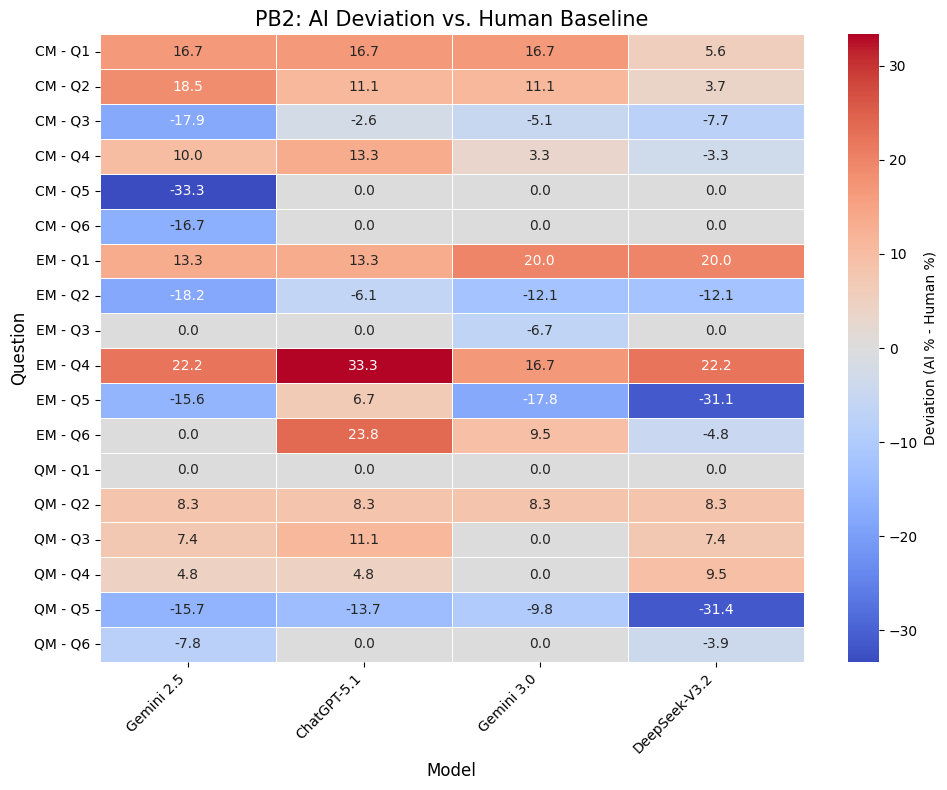

In [13]:
# Pivot table loop
for current_dir in ['P2']:
    # ==========================================
    # --- DRAW THE DEVIATION HEATMAP ---
    # ==========================================
    deviation_df = pd.DataFrame()
    y_labels = question_pivot['Sheet'].astype(str) + " - Q" + question_pivot['Question Number'].astype(str)
    
    for model in ai_models:
        if model in question_pivot.columns and question_pivot[model].notna().any():
            deviation_df[model] = question_pivot[model] - question_pivot['Human']
            
    if not deviation_df.empty:
        deviation_df.index = y_labels

        fig_height = max(8, len(deviation_df) * 0.4) 
        plt.figure(figsize=(10, fig_height))
        
        sns.heatmap(
            deviation_df, 
            cmap='coolwarm', 
            center=0, 
            annot=True,         
            fmt=".1f",          
            linewidths=0.5,     
            cbar_kws={'label': 'Deviation (AI % - Human %)'}
        )

        plt.title(f'AI Deviation vs. Human Baseline per Question')
        plt.ylabel('Question ID (Sheet - Question Number)')
        plt.xlabel('AI Model')
        plt.xticks(rotation=45, ha='right')

        plt.title(f'PB2: AI Deviation vs. Human Baseline', fontsize=15)
        plt.ylabel('Question', fontsize=12)
        plt.xlabel('Model', fontsize=12)
        plt.xticks(rotation=45, ha='right')


        # Save figure
        output_dir = '../Plots/Heat_Maps'
        os.makedirs(output_dir, exist_ok=True)
        plt.savefig(os.path.join(output_dir, f'AIM_MS_Heat_Map'), dpi=300, bbox_inches='tight')
        
        plt.tight_layout()
        plt.show()

# Topic Lingress

/var/folders/17/723pj1316pl5m9z25hgjlqbc0000gn/T/ipykernel_93437/1167075777.py:10: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  question_pivot = topic_df.pivot_table(



--- Alignment & IRR Statistics for Directory: P2 ---
        Model  Gradient (Slope)  Y-Intercept  Pearson r (IRR)  R-squared  MAE (Avg Disagreement %)  RMSE vs Human (%)  Slope Std Error
   Gemini 2.5           -0.0389      83.7688          -0.0388     0.0015                   18.8557            20.1319           0.5004
  ChatGPT-5.1            0.6336      37.3052           0.8414     0.7080                    7.2792             9.8792           0.2035
   Gemini 3.0            0.8484      17.1100           0.8543     0.7299                    6.0399             8.5503           0.2581
DeepSeek-V3.2            1.0435      -3.9609           0.9572     0.9162                    3.3808             4.3754           0.1578



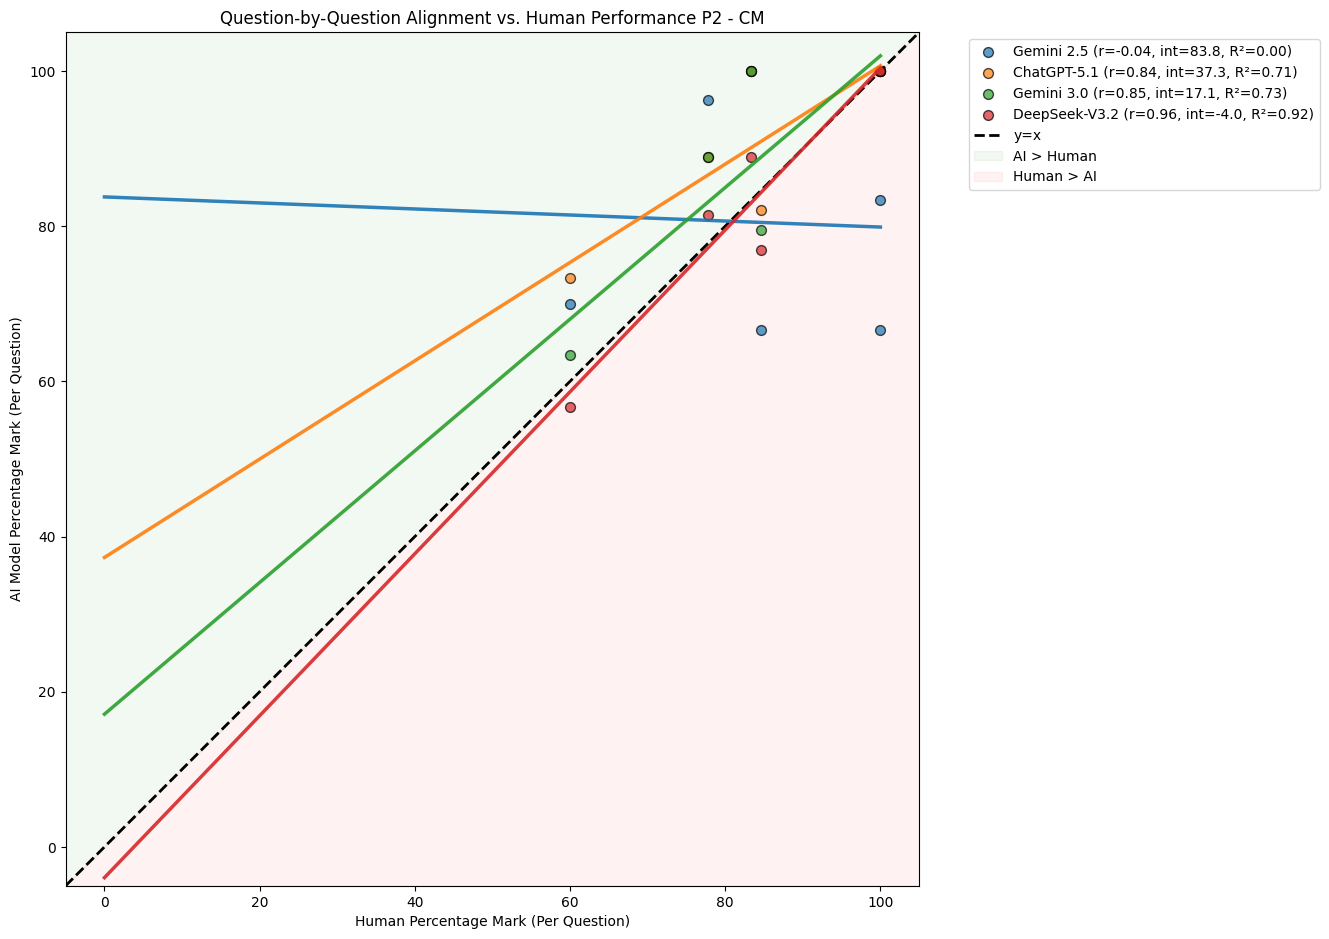


--- Alignment & IRR Statistics for Directory: P2 ---
        Model  Gradient (Slope)  Y-Intercept  Pearson r (IRR)  R-squared  MAE (Avg Disagreement %)  RMSE vs Human (%)  Slope Std Error
   Gemini 2.5            0.8006      12.1800           0.9049     0.8188                   11.5488            14.4000           0.1883
  ChatGPT-5.1            0.6541      32.4508           0.9560     0.9140                   13.8672            17.9674           0.1003
   Gemini 3.0            0.8355      11.4046           0.9035     0.8164                   13.7927            14.5825           0.1981
DeepSeek-V3.2            0.8865       5.7996           0.8575     0.7353                   15.0361            18.3999           0.2660



/var/folders/17/723pj1316pl5m9z25hgjlqbc0000gn/T/ipykernel_93437/1167075777.py:10: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  question_pivot = topic_df.pivot_table(


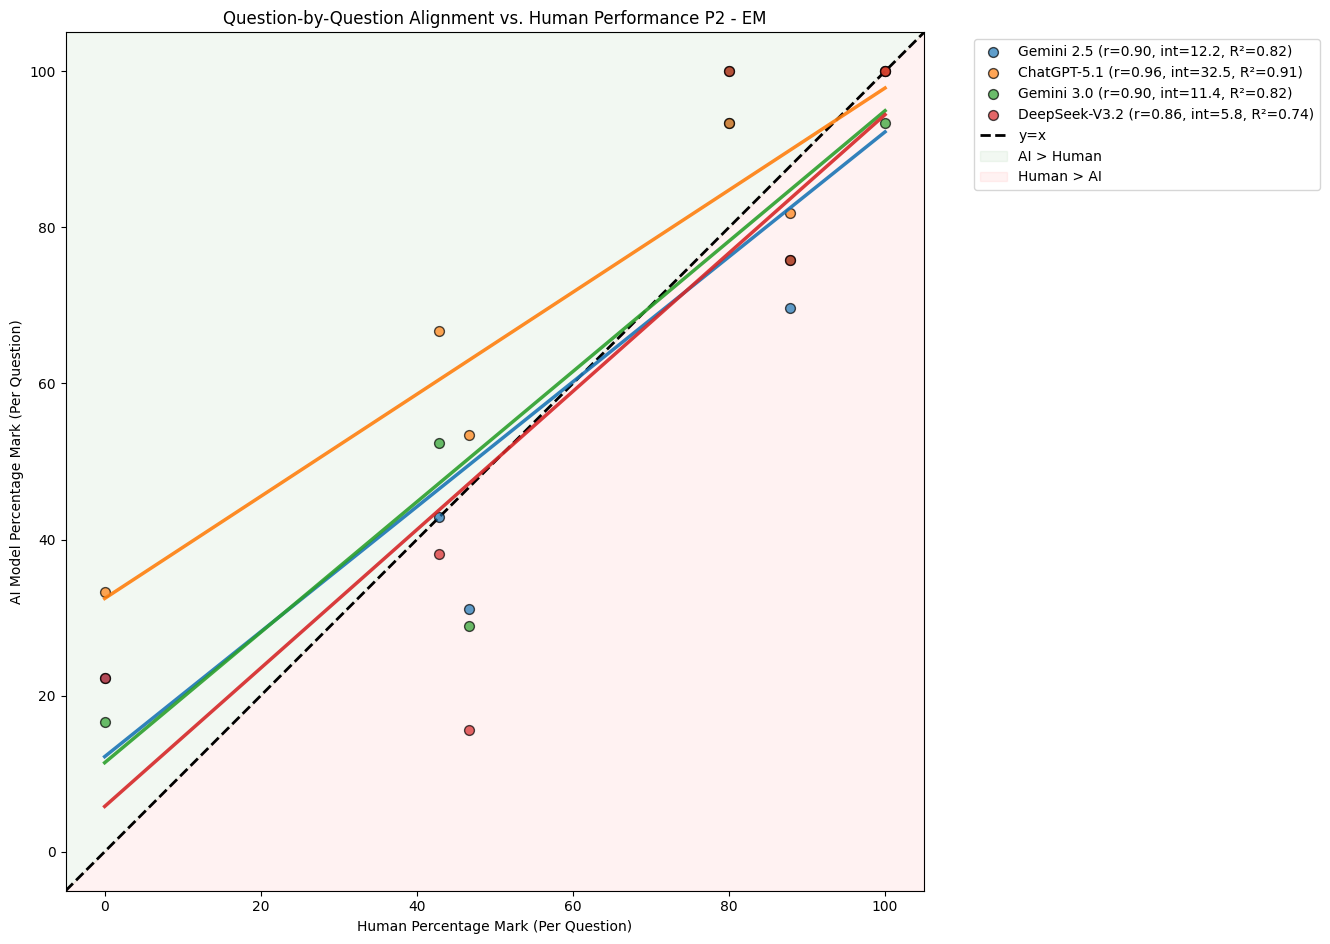

/var/folders/17/723pj1316pl5m9z25hgjlqbc0000gn/T/ipykernel_93437/1167075777.py:10: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  question_pivot = topic_df.pivot_table(



--- Alignment & IRR Statistics for Directory: P2 ---
        Model  Gradient (Slope)  Y-Intercept  Pearson r (IRR)  R-squared  MAE (Avg Disagreement %)  RMSE vs Human (%)  Slope Std Error
   Gemini 2.5            1.1156     -10.6860           0.7852     0.6166                    7.3387             8.7041           0.4398
  ChatGPT-5.1            1.1888     -14.8870           0.8308     0.6902                    6.3220             8.2053           0.3983
   Gemini 3.0            1.2832     -25.1913           0.9425     0.8884                    3.0229             5.2530           0.2274
DeepSeek-V3.2            1.5079     -46.4219           0.7450     0.5550                   10.0931            14.2281           0.6752



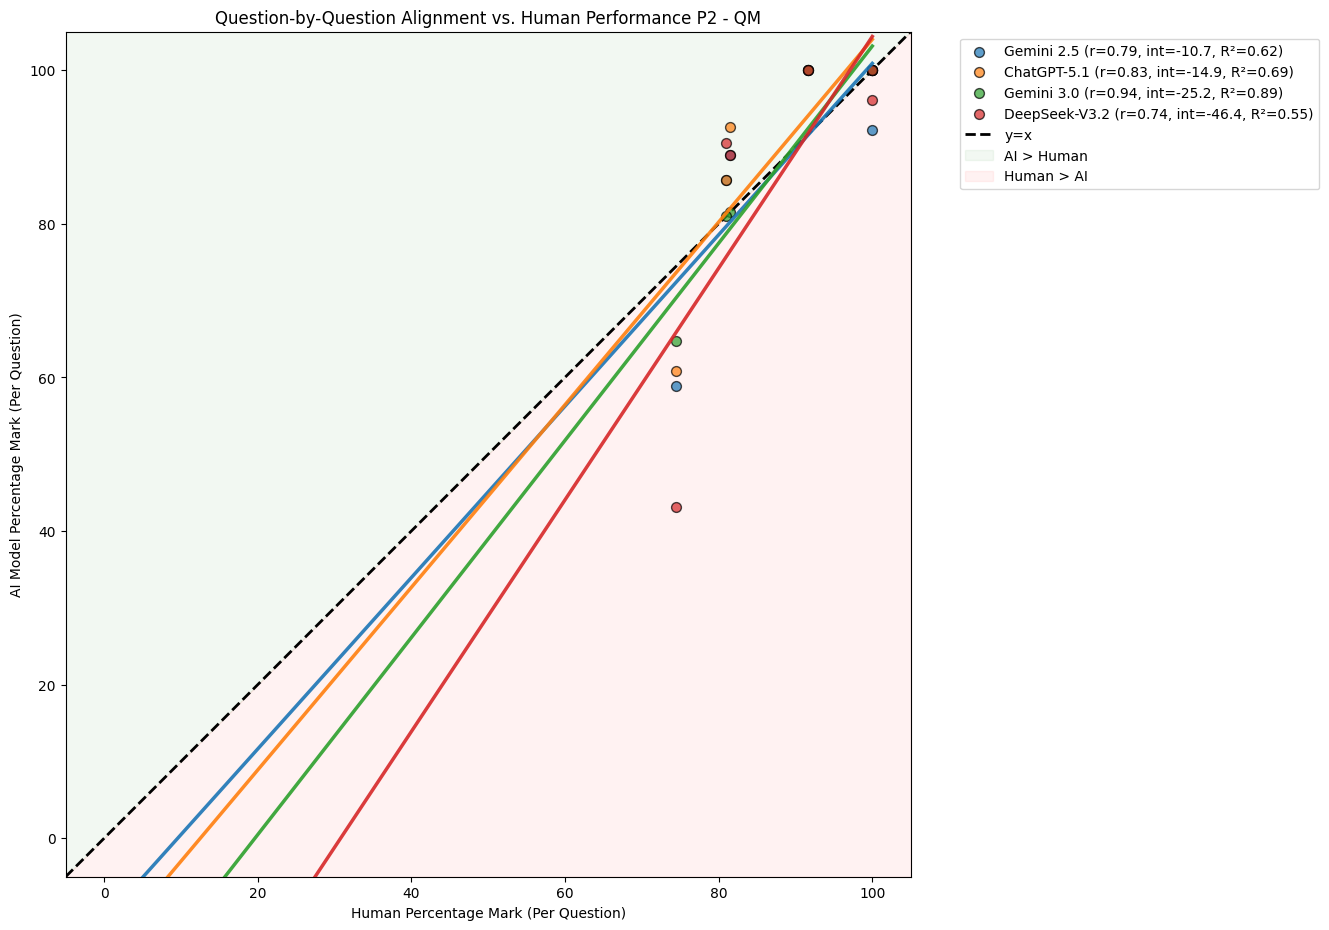

In [55]:
# Pivot table loop
for current_dir in ['P2']:
    for sheet in sheet_list:
        # Filter the master_df for just this specific directory
        dir_df = master_df[master_df['Dir'] == current_dir]
        topic_df = dir_df[dir_df['Sheet'] == sheet]


        # Pivot the data for just this directory
        question_pivot = topic_df.pivot_table(
            index=['Sheet', 'Question Number'], 
            columns='Model', 
            values='mean percentage mark' 
        ).reset_index()

        fig, ax = plt.subplots(figsize=(12, 10))

        # Separate AI models from the Human baseline (preserves your original list order)
        ai_models = [m for m in model_list if m in question_pivot.columns and m != 'Human']
        
        # List to store our text statistics
        stats_list = []

        # Plot linear regression
        for i, model in enumerate(ai_models):
            if question_pivot[model].notna().any():
                x = question_pivot['Human'].astype(float)
                y = question_pivot[model].astype(float)
            
                # A. Calculate Linear Regression with scipy FIRST
                res = linregress(x, y)
                slope, intercept = res.slope, res.intercept
                slope_stderr = res.stderr
                pearson_r = res.rvalue        
                r_squared = pearson_r ** 2    
                
                # Calculate RMSE and MAE vs Human logic
                rmse = np.sqrt(np.mean((y - x)**2))
                mae = np.mean(np.abs(y - x))  
                
                # Save stats for the text printout 
                stats_list.append({
                    'Model': model,
                    'Gradient (Slope)': slope,
                    'Y-Intercept': intercept,
                    'Pearson r (IRR)': pearson_r,
                    'R-squared': r_squared,
                    'MAE (Avg Disagreement %)': mae,
                    'RMSE vs Human (%)': rmse,
                    'Slope Std Error': slope_stderr
                })

                # B. Draw the Scatter Points 
                label_text = f"{model} (r={pearson_r:.2f}, int={intercept:.1f}, R²={r_squared:.2f})"
                ax.scatter(x, y, label=label_text, color=colors[i], 
                        s=50, alpha=0.7, edgecolors='black', zorder=3)
                
                # C. Draw the Regression Line
                x_vals = np.array([0, 100]) 
                y_vals = slope * x_vals + intercept
                ax.plot(x_vals, y_vals, color=colors[i], linestyle='-', 
                        linewidth=2.5, alpha=0.9, zorder=4)

        # ==========================================
        # --- PRINT THE TEXT STATISTICS ---
        # ==========================================
        print(f"\n{'='*135}")
        print(f"--- Alignment & IRR Statistics for Directory: {current_dir} ---")
        print(f"{'='*135}")
        if stats_list:
            stats_df = pd.DataFrame(stats_list)
            # REMOVED SORTING: Data prints exactly in the order of model_list
            print(stats_df.to_string(index=False, float_format="%.4f"))
        else:
            print("No comparative data available.")
        print(f"{'='*135}\n")

        # ==========================================
        # --- DRAW THE SCATTER PLOT ---
        # ==========================================
        min_val, max_val = -5, 105
        ax.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=2, label='y=x', zorder=2)

        ax.set_xlabel('Human Percentage Mark (Per Question)')
        ax.set_ylabel('AI Model Percentage Mark (Per Question)')
        ax.set_title(f'Question-by-Question Alignment vs. Human Performance {current_dir} - {sheet}')

        ax.fill_between([min_val, max_val], [min_val, max_val], max_val, color='green', alpha=0.05, label='AI > Human')
        ax.fill_between([min_val, max_val], min_val, [min_val, max_val], color='red', alpha=0.05, label='Human > AI')

        ax.set_aspect('equal', adjustable='box')
        ax.set_xlim(min_val, max_val)
        ax.set_ylim(min_val, max_val)

        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

        plt.tight_layout()
        plt.show()